# Preambolo

In [ ]:
import numpy as np
import matplotlib as mtp
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import math
import sys
from scipy.stats import norm
from scipy.stats import chi2
from matplotlib.ticker import FormatStrFormatter
from scipy import stats
from scipy.constants import g
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import StrMethodFormatter
!pip install uncertainties
from uncertainties import ufloat
import uncertainties.umath
from uncertainties.umath import sin
from uncertainties import unumpy as unp
from uncertainties.umath import sqrt
from uncertainties import ufloat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
import os
import sys
import shutil

%cd /content/
if os.path.exists('/content/Esperienze-in-laboratorio'):
    shutil.rmtree('/content/Esperienze-in-laboratorio')

!git clone https://github.com/matteodeclich/Esperienze-in-laboratorio.git

percorso_libreria = '/content/Esperienze-in-laboratorio/Libreria_python'
if percorso_libreria not in sys.path:
    sys.path.insert(0, percorso_libreria)

try:
    from analisi_dati import *
    print("✅ Tutto pronto! Librerie installate e modulo importato.")
except Exception as e:
    print(f"❌ Errore durante l'import: {e}")

%cd Esperienze-in-laboratorio
%cd Banco ottico

/content
Cloning into 'Esperienze-in-laboratorio'...
remote: Enumerating objects: 1457, done.
remote: Counting objects: 100% (364/364), done.
remote: Compressing objects: 100% (229/229), done.
remote: Total 1457 (delta 172), reused 316 (delta 126), pack-reused 1093 (from 1)
Receiving objects: 100% (1457/1457), 18.31 MiB | 29.03 MiB/s, done.
Resolving deltas: 100% (742/742), done.
✅ Tutto pronto! Librerie installate e modulo importato.
/content/Esperienze-in-laboratorio
/content/Esperienze-in-laboratorio/Banco ottico


# Pull

In [ ]:
!git pull

Already up to date.


# Legge di Rifrazione e Reversibilità dei Cammini Ottici

Misura degli angoli di rifrazione dal lato piatto e curvo di un semicilindro di plexiglass



In [ ]:
df=pd.read_excel("Banco ottico.xlsx", sheet_name=0)
df=df.fillna('')
df

,Unnamed: 0,Unnamed: 1,Lato piatto,Unnamed: 3,Lato curvo,Unnamed: 5,Unnamed: 6
0,θ inc,sinθ inc,θ rif,sinθ rif,θ rif,sinθ rif,θ critico
1,20,0.34202,13,0.224951,30,0.5,44
2,25,0.422618,16,0.275637,39,0.62932,
3,30,0.5,20,0.34202,48,0.743145,
4,45,0.707107,28,0.469472,136,0.694658,
5,60,0.866025,35,0.573576,120,0.866025,
6,70,0.939693,39,0.62932,111,0.93358,
7,,,,,,,
8,Reversibilità,,θ' inc,θ' rif,θ' inc,θ' rif,
9,,,13,19,30,20,


Interpolazione dei dati per verificare la legge di Snell

Il risultato del fit y = k0·x è:
  k0 = 0.66620590±0.01066407


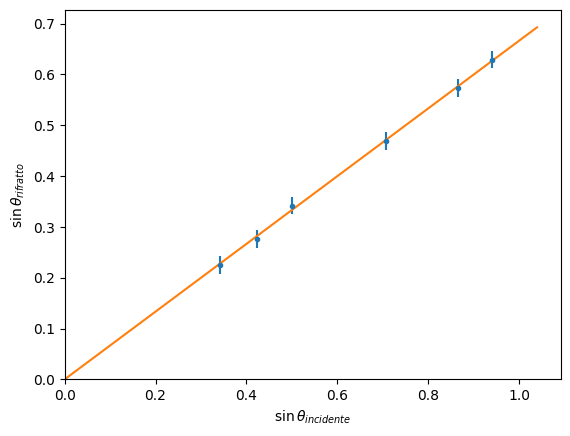

Il risultato del test del χ² è:
  χ²               = 0.48496779
  Gradi di libertà = 5
  χ² ridotto       = 0.096993559
  Il p-value associato è: 0.99266337
Il valore di n_exp è: 1.501±0.024
Il valore di n_teo è: 1.494±0.029
Test di compatibilità tra n_exp e n_teo: |t| = 0.17432276


In [ ]:
d_SinI = df.iloc[1:7, 1]
d_sSinI = np.full(len(d_SinI), np.pi/180)
sin_inc = unp.uarray(d_SinI, d_sSinI)

d_SinR = df.iloc[1:7, 3]
d_sSinR = np.full(len(d_SinR), np.pi/180)
sin_rif = unp.uarray(d_SinR, d_sSinR)

x = sin_inc
y = sin_rif


k0 = minquadw_kx(unp.nominal_values(x), unp.nominal_values(y), unp.std_devs(y), "k0" )

def retta(x, k0):
    return x * k0

t = np.linspace(0, max(unp.nominal_values(x))+0.1, 100)

plt.errorbar(unp.nominal_values(x), unp.nominal_values(y), yerr=unp.std_devs(y), fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k0.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel(r'$\sin\theta_{incidente}$')
plt.ylabel(r'$\sin\theta_{rifratto}$')
plt.show()

print("="*70)
chi_quadro(unp.nominal_values(y), x*k0, unp.std_devs(y), 1);
print("="*70)

n_exp = 1/k0
print(f"Il valore di n_exp è: {n_exp:.4P}")

theta_lim = ufloat(42*np.pi/180, np.pi/180)
n_teo = 1/sin(theta_lim)
print(f"Il valore di n_teo è: {n_teo:.4P}")

print("="*70)
t_test(n_exp, n_teo, nome1="n_exp", nome2="n_teo");
print("="*70)

In [ ]:
theta_i=unp.uarray(df.iloc[1:7, 0], 1)
theta_primo_r=unp.uarray(df.iloc[9:15, 3], 1)
theta_primo_r2=unp.uarray(df.iloc[9:15, 5], 1)
for i in range(len(theta_primo_r)):
  t1=np.abs(unp.nominal_values(theta_primo_r[i])- unp.nominal_values(theta_i[i]))/sqrt(2)
  t2=np.abs(unp.nominal_values(theta_primo_r2[i])- unp.nominal_values(theta_i[i]))/sqrt(2)
  print(f"t_0 = {t1:.2f}")
print(f"="*10)
for i in range(len(theta_primo_r)):
  t2=np.abs(unp.nominal_values(theta_primo_r2[i])- unp.nominal_values(theta_i[i]))/sqrt(2)
  print(f"t_0 = {t2:.2f}")

theta_primo_r2=unp.uarray(df.iloc[15:21, 3], 1)

t_0 = 0.71
t_0 = 0.71
t_0 = 0.00
t_0 = 0.71
t_0 = 2.12
t_0 = 1.41
t_0 = 0.00
t_0 = 0.00
t_0 = 0.00
t_0 = 0.00
t_0 = 1.41
t_0 = 0.71


# Angolo di Deviazione Minima

Misura dell'angolo di deviazione minima per ricavare l'indice di rifrazione di vetro e plexiglass.

In [ ]:
df1=pd.read_excel("Banco ottico.xlsx", sheet_name=1)
df1=df1.fillna('')
df1

,Unnamed: 0,δ minimo (rad),α (rad),n,σn
0,prisma a base triangolare,0.785398,1.047198,1.586707,0.015038
1,prisma a base trapezioidale,0.471239,0.785398,1.535957,0.020991
2,,,,,
3,h prisma trapezoidale,32mm (1mm),,,
4,,,,,
5,ANGOLI,Distanza dal centro [mm],Distanza attesa [mm],Seno,Coseno
6,10,2,1.970942,0.173648,0.984808
7,20,4,4.076306,0.34202,0.939693
8,30,6,6.458965,0.5,0.866025
9,40,9,9.273809,0.642788,0.766044


In [ ]:
delta1 = ufloat(np.pi/4, np.pi/180)
alfa1 = ufloat(np.pi/3, np.pi/180)
delta2 = ufloat(27*np.pi/180, np.pi/180)
alfa2 = ufloat(np.pi/4, np.pi/180)

n1 = sin((delta1+alfa1)/2)/sin(alfa1/2)
n2 = sin((delta2+alfa2)/2)/sin(alfa2/2)
print("="*70)
print(f"L'indice di rifrazione del prisma a base triangolare è: {n1:.4P}")
print(f"L'indice di rifrazione del prisma a base trapezoidale è: {n2:.4P}")
print("="*70)

L'indice di rifrazione del prisma a base triangolare è: 1.587±0.017
L'indice di rifrazione del prisma a base trapezoidale è: 1.536±0.023


In [ ]:
t_test(n2, n_exp);
t_test(n2, n_teo);

Test di compatibilità tra misura 1 e misura 2: |t| = 1.0475515
Test di compatibilità tra misura 1 e misura 2: |t| = 1.1194351


# Lastra a Facce Parallele

In [ ]:
d_dexp = df1.iloc[6:11, 1]
d_sdexp= np.full(len(d_dexp), 1)
d_exp = unp.uarray(d_dexp, d_sdexp)

h = ufloat(32, 1)

d_th = df1.iloc[6:11, 0]/180*np.pi
d_sth = np.full(len(d_th), np.pi/180)
th = unp.uarray(d_th, d_sth)

d_teo = h*unp.sin(th)*(1-unp.cos(th)/unp.sqrt(n2**2-unp.sin(th)**2))

print("="*70)
for i, valore in enumerate(d_teo):
    misura = d_exp[i]
    print(f"d_exp = {misura:.3P}, d_teo = {valore:.3P}")
    t_test(misura, valore, nome1="d_dexp", nome2="d_teo")
    print("="*70)

d_exp = 2.00±1.00, d_teo = 1.97±0.22
Test di compatibilità tra d_dexp e d_teo: |t| = 0.028392805
d_exp = 4.00±1.00, d_teo = 4.08±0.28
Test di compatibilità tra d_dexp e d_teo: |t| = 0.073517898
d_exp = 6.00±1.00, d_teo = 6.46±0.36
Test di compatibilità tra d_dexp e d_teo: |t| = 0.4312489
d_exp = 9.00±1.00, d_teo = 9.27±0.47
Test di compatibilità tra d_dexp e d_teo: |t| = 0.24773744
d_exp = 12.0±1.0, d_teo = 12.7±0.6
Test di compatibilità tra d_dexp e d_teo: |t| = 0.58247514


# Lenti Sottili: 250mm

In [ ]:
df2=pd.read_excel("Banco ottico.xlsx", sheet_name=2)
df2=df2.fillna('')
df2

,Unnamed: 0,Fuoco 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Fuoco 2,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,D totale,p (mm),q (mm),h' (mm),M misurato,M atteso,p (mm),q (mm),h' (mm),M misurato,M atteso,DISTANZA FOCALE 1,DISTANZA FOCALE 2,D. MINIMA OSS.,D. MINIMA TEOR.
1,1100,390,710,77,1.925,1.820513,720,380,22,0.55,0.527778,251.727273,248.727273,999mm,1000 mm
2,1200,355,845,100,2.5,2.380282,850,350,18,0.45,0.411765,249.979167,247.916667,,
3,1300,340,960,119,2.975,2.823529,968,332,15,0.375,0.342975,251.076923,247.212308,,
4,1400,329,1071,137,3.425,3.255319,1074,326,13,0.325,0.303538,251.685,250.088571,,
5,1500,319,1181,155,3.875,3.702194,1186,314,12,0.3,0.264755,251.159333,248.269333,,


Il risultato del fit y = a + b·x è:
  a = 0.0040403778±0.0000507202
  b = -1.0196732±0.0169189
  Covarianza cov(a, b) = -8.5474927e-07
Risultati della regressione:
Pendenza (b): -1.020±0.017
Intercetta (a): 0.004040±0.000051
Distanza focale sperimentale: 247.5±3.1 mm


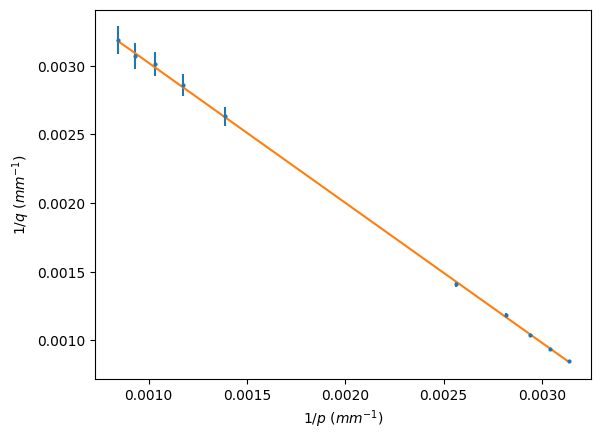

Il risultato del test del χ² è:
  χ²               = 3.0338619
  Gradi di libertà = 8
  χ² ridotto       = 0.37923274
  Il p-value associato è: 0.93221458
Compatibilità di f1 con 250: |t| = 0.80412499


In [ ]:
d_p1 = df2.iloc[1:6, [1, 6]]
d_q1 = df2.iloc[1:6, [2, 7]]
d_p1_flat = d_p1.values.flatten()
d_q1_flat = d_q1.values.flatten()
d_sp1 = np.full(len(d_p1_flat), 10)
d_sq1 = np.full(len(d_q1_flat), 10)

p1 = unp.uarray(d_p1_flat, d_sp1)
q1 = unp.uarray(d_q1_flat, d_sq1)

x1 = 1/p1
y1 = 1/q1

a1, b1, cov_ab = minquadw_abx(unp.nominal_values(x1), unp.nominal_values(y1), unp.std_devs(y1));

f1_sperimentale= 1/a1

print("="*70)
print("Risultati della regressione:")
print(f"Pendenza (b): {b1:.4P}")
print(f"Intercetta (a): {a1:.4P}")
print(f"Distanza focale sperimentale: {f1_sperimentale:.4P} mm")
print("="*70)

def retta_1(x, a, b):
    return a + b*x

t= np.linspace(min(unp.nominal_values(x1)), max(unp.nominal_values(x1)), 36)
plt.errorbar(unp.nominal_values(x1), unp.nominal_values(y1), yerr=unp.std_devs(y1), fmt='o', ls='none', label='Dati', ms=2)

plt.plot(t, retta_1(t, a1.nominal_value, b1.nominal_value))

plt.xticks()
plt.xlabel(r'$1/p$ $(mm^{-1})$')
plt.ylabel(r'$1/q$ $(mm^{-1})$')
plt.show()

print("="*70)
chi_quadro(unp.nominal_values(y1), a1 + b1*x1, unp.std_devs(y1), 2);
print("="*70)
compatibilita_valore(f1_sperimentale, 250, nome="f1");
print("="*70)

Calcolo del coefficiente di ingrandimento e test di compatibilità tra ingrandimento sperimentale ($h_{finale}/h_0$) e ingrandimento teorico ($q/p$)

In [ ]:
H0 = ufloat(40, 1)

d_h1 = df2.iloc[1:, [3, 8]]
d_sh1 = np.full(len(d_h1.values.flatten()), 1)
h1 = unp.uarray(d_h1.values.flatten(), d_sh1)

M1 = h1/H0
M1_teo = q1/p1

print("="*70)
for i, valore in enumerate(M1_teo):
    misura = M1[i]
    print(f"M1 = {misura:.4P}, M1_teo = {valore:.4P}")
    t_test(misura, valore, nome1="d_dexp", nome2="d_teo")
    print("="*70)

M1 = 1.925±0.054, M1_teo = 1.821±0.053
Test di compatibilità tra d_dexp e d_teo: |t| = 1.3746548
M1 = 0.5500±0.0285, M1_teo = 0.5278±0.0157
Test di compatibilità tra d_dexp e d_teo: |t| = 0.68232608
M1 = 2.500±0.067, M1_teo = 2.380±0.073
Test di compatibilità tra d_dexp e d_teo: |t| = 1.2080764
M1 = 0.4500±0.0274, M1_teo = 0.4118±0.0127
Test di compatibilità tra d_dexp e d_teo: |t| = 1.2651002
M1 = 2.975±0.078, M1_teo = 2.824±0.088
Test di compatibilità tra d_dexp e d_teo: |t| = 1.2839183
M1 = 0.3750±0.0267, M1_teo = 0.3430±0.0109
Test di compatibilità tra d_dexp e d_teo: |t| = 1.1101497
M1 = 3.425±0.089, M1_teo = 3.255±0.104
Test di compatibilità tra d_dexp e d_teo: |t| = 1.2417995
M1 = 0.3250±0.0263, M1_teo = 0.3035±0.0097
Test di compatibilità tra d_dexp e d_teo: |t| = 0.76566518
M1 = 3.875±0.100, M1_teo = 3.702±0.120
Test di compatibilità tra d_dexp e d_teo: |t| = 1.1048829
M1 = 0.3000±0.0261, M1_teo = 0.2648±0.0087
Test di compatibilità tra d_dexp e d_teo: |t| = 1.2807073


In [ ]:
# Scegli il formato che preferisci:
# Per una tabella di testo/Markdown standard (usa il simbolo ±)
formato_stringa = "{:.3f} ± {:.3f}"

# Per il codice sorgente LaTeX (usa \pm racchiuso tra $)
# formato_stringa = "${:.3f} \\pm {:.3f}$"

# Estraiamo i dati formattati ciclando direttamente sugli uarray
colonna_M1 = [
    formato_stringa.format(n, s)
    for n, s in zip(unp.nominal_values(M1), unp.std_devs(M1))
]
colonna_M1_teo = [
    formato_stringa.format(n, s)
    for n, s in zip(unp.nominal_values(M1_teo), unp.std_devs(M1_teo))
]

# Costruiamo il DataFrame finale
df_confronto = pd.DataFrame(
    {"M1 (Sperimentale)": colonna_M1, "M1_teo (Teorico)": colonna_M1_teo}
)

# Visualizza la tabella
print(df_confronto)

  M1 (Sperimentale) M1_teo (Teorico)
0     1.925 ± 0.054    1.821 ± 0.053
1     0.550 ± 0.029    0.528 ± 0.016
2     2.500 ± 0.067    2.380 ± 0.073
3     0.450 ± 0.027    0.412 ± 0.013
4     2.975 ± 0.078    2.824 ± 0.088
5     0.375 ± 0.027    0.343 ± 0.011
6     3.425 ± 0.089    3.255 ± 0.104
7     0.325 ± 0.026    0.304 ± 0.010
8     3.875 ± 0.100    3.702 ± 0.120
9     0.300 ± 0.026    0.265 ± 0.009


# Lenti Sottili: 100mm

In [ ]:
df3=pd.read_excel("Banco ottico.xlsx", sheet_name=3)
df3=df3.fillna('')
df3

,Unnamed: 0,Fuoco 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Fuoco 2,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,D totale,p (mm),q (mm),h',M misurato,M atteso,p (mm),q (mm),h',M misurato,M atteso,DISTANZA FOCALE 1,DISTANZA FOCALE 2,D. MINIMA OSS.,D. MINIMA TEOR.
1,600,139,461,146,3.65,3.316547,467,133,13,0.325,0.284797,106.798333,103.518333,405 mm,400 mm
2,550,146,404,120,3,2.767123,413,137,15,0.375,0.331719,107.243636,102.874545,,
3,500,155,345,98,2.45,2.225806,355,145,19,0.475,0.408451,106.95,102.95,,
4,450,173,277,68,1.7,1.601156,285,165,26,0.65,0.578947,106.491111,104.5,,


Interpolazione di $1/p$ verso $1/q$ per verificare la legge dei punti coniugati con la lente di lunghezza focale 100 mm.

Il risultato del fit y = a + b·x è:
  a = 0.0097090120±0.0003281590
  b = -1.0515853±0.0479452
  Covarianza cov(a, b) = -1.5655488e-05
Risultati della regressione:
Pendenza (b): -1.052±0.048
Intercetta (a): 0.0097090±0.0003282
Distanza focale sperimentale: 103.0±3.5 mm


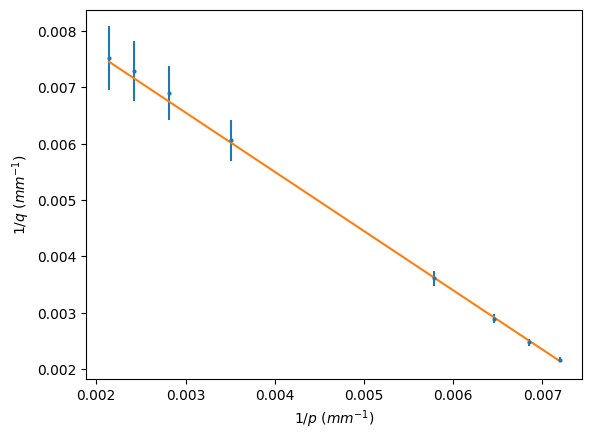

Il risultato del test del χ² è:
  χ²               = 0.86265061
  Gradi di libertà = 6
  χ² ridotto       = 0.1437751
  Il p-value associato è: 0.99028768
Compatibilità di f1 con 100: |t| = 0.8609258


In [ ]:
d_p2 = df3.iloc[1:5, [1, 6]]
d_q2 = df3.iloc[1:5, [2, 7]]
d_p2_flat = d_p2.values.flatten()
d_q2_flat = d_q2.values.flatten()
d_sp2 = np.full(len(d_p2_flat), 10)
d_sq2 = np.full(len(d_q2_flat), 10)

p2 = unp.uarray(d_p2_flat, d_sp2)
q2 = unp.uarray(d_q2_flat, d_sq2)

x2 = 1/p2
y2 = 1/q2

a2, b2, cov_ab = minquadw_abx(unp.nominal_values(x2), unp.nominal_values(y2), unp.std_devs(y2))

f2_sperimentale= 1/a2

print("="*70)
print("Risultati della regressione:")
print(f"Pendenza (b): {b2:.4P}")
print(f"Intercetta (a): {a2:.5P}")
print(f"Distanza focale sperimentale: {f2_sperimentale:.4P} mm")
print("="*70)

t= np.linspace(min(unp.nominal_values(x2)), max(unp.nominal_values(x2)), 36)
plt.errorbar(unp.nominal_values(x2), unp.nominal_values(y2), yerr=unp.std_devs(y2), fmt='o', ls='none', label='Dati', ms=2)
plt.xticks()
plt.plot(t, retta_1(t, a2.nominal_value, b2.nominal_value))
plt.xlabel(r'$1/p$ $(mm^{-1})$')
plt.ylabel(r'$1/q$ $(mm^{-1})$')
plt.show()


print("="*70)
chi_quadro(unp.nominal_values(y2), a2 + b2*x2, unp.std_devs(y2), 2);
print("="*70)
compatibilita_valore(f2_sperimentale, 100, nome="f1");
print("="*70)

Calcolo del coefficiente di ingrandimento e test di compatibilità tra ingrandimento sperimentale ($h_{finale}/h_0$) e ingrandimento teorico ($q/p$)

In [ ]:
d_h2 = df3.iloc[1:, [3, 8]]
d_sh2 = np.full(len(d_h2.values.flatten()), 1)
h2 = unp.uarray(d_h2.values.flatten(), d_sh2)

M2_exp = h2/H0
M2_teo = q2/p2


print("="*70)
for i, valore in enumerate(M2_teo):
    misura = M2_exp[i]
    print(f"M2_exp = {misura:.4P}, M2_teo = {valore:.4P}")
    t_test(misura, valore, nome1="M2_exp", nome2="M2_teo")
    print("="*70)

M2_exp = 3.650±0.095, M2_teo = 3.317±0.249
Test di compatibilità tra M2_exp e M2_teo: |t| = 1.2509215
M2_exp = 0.3250±0.0263, M2_teo = 0.2848±0.0223
Test di compatibilità tra M2_exp e M2_teo: |t| = 1.1670413
M2_exp = 3.000±0.079, M2_teo = 2.767±0.202
Test di compatibilità tra M2_exp e M2_teo: |t| = 1.0757543
M2_exp = 0.3750±0.0267, M2_teo = 0.3317±0.0255
Test di compatibilità tra M2_exp e M2_teo: |t| = 1.1720346
M2_exp = 2.450±0.066, M2_teo = 2.226±0.157
Test di compatibilità tra M2_exp e M2_teo: |t| = 1.3128937
M2_exp = 0.4750±0.0277, M2_teo = 0.4085±0.0304
Test di compatibilità tra M2_exp e M2_teo: |t| = 1.6179218
M2_exp = 1.700±0.049, M2_teo = 1.601±0.109
Test di compatibilità tra M2_exp e M2_teo: |t| = 0.82546595
M2_exp = 0.6500±0.0298, M2_teo = 0.5789±0.0405
Test di compatibilità tra M2_exp e M2_teo: |t| = 1.4118026


In [ ]:
# Estraiamo i dati formattati ciclando direttamente sugli uarray
colonna_M2 = [
    formato_stringa.format(n, s)
    for n, s in zip(unp.nominal_values(M2_exp), unp.std_devs(M2_exp))
]
colonna_M2_teo = [
    formato_stringa.format(n, s)
    for n, s in zip(unp.nominal_values(M2_teo), unp.std_devs(M2_teo))
]

# Costruiamo il DataFrame finale
df_confronto = pd.DataFrame(
    {"M2 (Sperimentale)": colonna_M2, "M2_teo (Teorico)": colonna_M2_teo}
)

# Visualizza la tabella
print(df_confronto)

  M2 (Sperimentale) M2_teo (Teorico)
0     3.650 ± 0.095    3.317 ± 0.249
1     0.325 ± 0.026    0.285 ± 0.022
2     3.000 ± 0.079    2.767 ± 0.202
3     0.375 ± 0.027    0.332 ± 0.026
4     2.450 ± 0.066    2.226 ± 0.157
5     0.475 ± 0.028    0.408 ± 0.030
6     1.700 ± 0.049    1.601 ± 0.109
7     0.650 ± 0.030    0.579 ± 0.041
